In [1]:
import pandas as pd
import numpy as np

# 1. Load the dataset
# Note: For this dataset, writing encoding='latin1' is very important
df = pd.read_csv("C:\\Users\\Pankaj\\OneDrive\\Documents\\DataCoSupplyChainDataset.csv", encoding='latin1')

# 2. To check Total rows and columns 
print("Dataset has been successfully load !")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")

# 3. for 1st 5 rows
df.head()

C:\Users\Pankaj\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Pankaj\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Dataset has been successfully load !
Total Rows: 180519, Total Columns: 53


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,02-03-2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## data preprocessing(filtering and feature engineering)

In [3]:
# 1. Filtering the necessary columns for Project FORESIGHT
required_columns = [
    'order date (DateOrders)', 
    'Product Card Id', 
    'Product Name',
    'Category Name',
    'Order Item Quantity', 
    'Sales',
    'Days for shipping (real)', 
    'Days for shipment (scheduled)'
]

df_clean = df[required_columns].copy()
# 2. Make the column names simple and clear
df_clean.columns = [
    'Date', 'Product_ID', 'Product_Name', 'Category', 
    'Quantity', 'Sales_Amount', 'Actual_Lead_Time', 'Scheduled_Lead_Time'
]

# 3. FIX: Safely convert the Date column with 'mixed' format
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='mixed', errors='coerce')

# 4. If any date could not be converted, then delete that row
df_clean = df_clean.dropna(subset=['Date'])

# 5. Feature Engineering: Creating new features
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Day'] = df_clean['Date'].dt.day
df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek  # 0=Monday, 6=Sunday

print("Data Preprocessing is completely success!")
print(f"New rows/columns's size: {df_clean.shape}")
df_clean.head()

Data Preprocessing is completely success!
New rows/columns's size: (180519, 12)


,Date,Product_ID,Product_Name,Category,Quantity,Sales_Amount,Actual_Lead_Time,Scheduled_Lead_Time,Year,Month,Day,DayOfWeek
0,2018-01-31 22:56:00,1360,Smart watch,Sporting Goods,1,327.75,3,4,2018,1,31,2
1,2018-01-13 12:27:00,1360,Smart watch,Sporting Goods,1,327.75,5,4,2018,1,13,5
2,2018-01-13 12:06:00,1360,Smart watch,Sporting Goods,1,327.75,4,4,2018,1,13,5
3,2018-01-13 11:45:00,1360,Smart watch,Sporting Goods,1,327.75,3,4,2018,1,13,5
4,2018-01-13 11:24:00,1360,Smart watch,Sporting Goods,1,327.75,2,4,2018,1,13,5


## Inventory Logic and Machine Learning Preparation

In [5]:
# 1. Calculate the average sales and shipping time for each product
product_metrics = df_clean.groupby('Product_ID').agg(
    Avg_Daily_Demand=('Quantity', 'mean'),
    Max_Lead_Time=('Actual_Lead_Time', 'max'),
    Avg_Lead_Time=('Actual_Lead_Time', 'mean')
).reset_index()

# 2. Formula for Safety Stock = (Max Lead Time - Avg Lead Time) * Avg Daily Demand
product_metrics['Safety_Stock'] = (
    product_metrics['Max_Lead_Time'] - product_metrics['Avg_Lead_Time']
) * product_metrics['Avg_Daily_Demand']

# 3. Formula for Reorder Point (ROP) = (Average Daily Demand * Average Lead Time) + Safety Stock
product_metrics['Reorder_Point'] = (
    product_metrics['Avg_Daily_Demand'] * product_metrics['Avg_Lead_Time']
) + product_metrics['Safety_Stock']

# 4. Merge these metrics with the processed dataset
df_ml = pd.merge(df_clean, product_metrics[['Product_ID', 'Safety_Stock', 'Reorder_Point']], on='Product_ID', how='left')

print("Inventory optimization metrics successfully calculated!")
print(f"Dataset shape for Machine Learning: {df_ml.shape}")
df_ml[['Product_ID', 'Quantity', 'Actual_Lead_Time', 'Safety_Stock', 'Reorder_Point']].head()

Inventory optimization metrics successfully calculated!
Dataset shape for Machine Learning: (180519, 14)


,Product_ID,Quantity,Actual_Lead_Time,Safety_Stock,Reorder_Point
0,1360,1,3,2.509804,6.0
1,1360,1,5,2.509804,6.0
2,1360,1,4,2.509804,6.0
3,1360,1,3,2.509804,6.0
4,1360,1,2,2.509804,6.0


## Machine Learning Model Training

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Select the input features (X) and the target variable we want to predict (y)
features = ['Year', 'Month', 'Day', 'DayOfWeek', 'Product_ID']
target = 'Quantity'

X = df_ml[features]
y = df_ml[target]

# 2. FIX: Changed test_test_split=0.2 to test_size=0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} rows")
print(f"Testing data size: {X_test.shape[0]} rows")

# 3. Initialize and train the Machine Learning model
print("\nTraining the Random Forest model... Please wait a few seconds...")
model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Model training complete!")

# 4. Evaluate the model performance on the test data
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f} units")
print(f"R-squared (R2 Score): {r2:.2f}")

# 5. Save the trained model data to a final dataframe for dashboard export later
df_ml['Predicted_Demand'] = model.predict(X)
df_ml.to_csv("foresight_final_processed.csv", index=False)
print("\nFinal processed data saved to 'foresight_final_processed.csv' for the dashboard!")

Training data size: 144415 rows
Testing data size: 36104 rows

Training the Random Forest model... Please wait a few seconds...
Model training complete!

Model Evaluation Metrics:
Mean Absolute Error (MAE): 0.68 units
R-squared (R2 Score): 0.46

Final processed data saved to 'foresight_final_processed.csv' for the dashboard!


## Data Visualization (EDA Graphs)

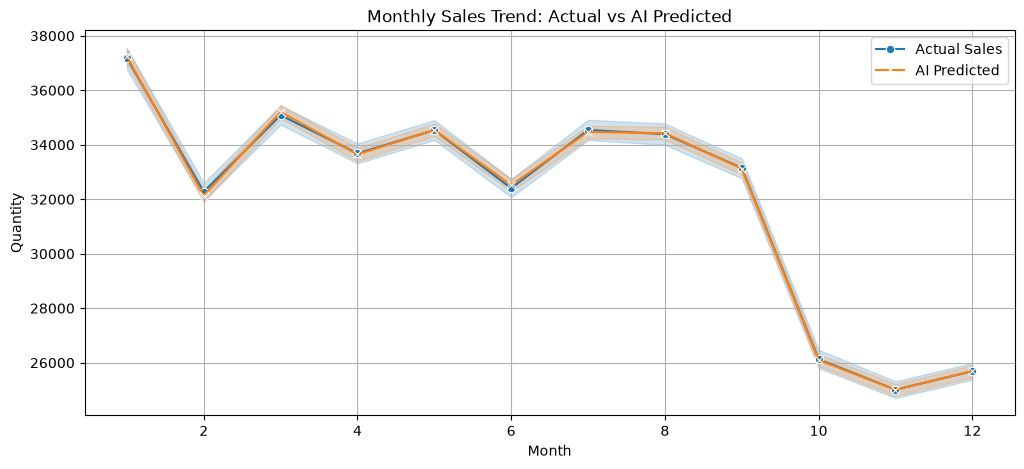

C:\Users\Pankaj\AppData\Local\Temp\ipykernel_22980\155363846.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


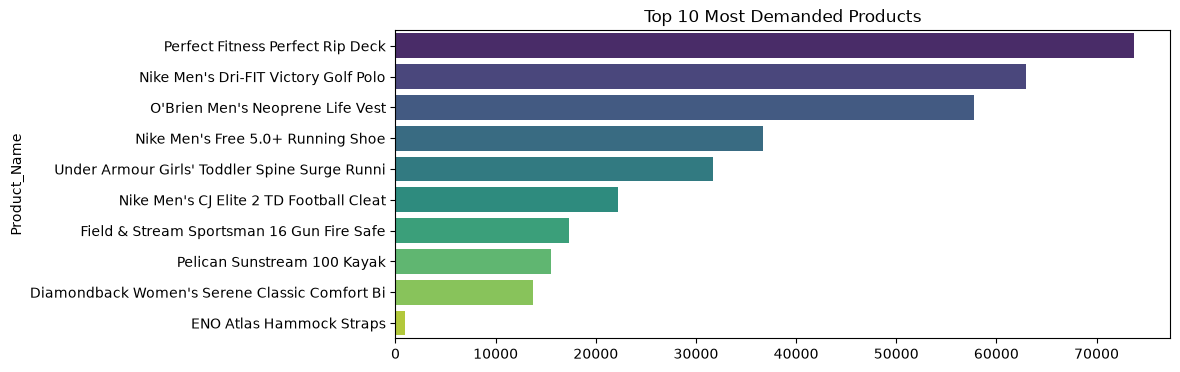

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Monthly Sales Trend Chart
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_ml, x='Month', y='Quantity', estimator='sum', marker='o', label='Actual Sales')
sns.lineplot(data=df_ml, x='Month', y='Predicted_Demand', estimator='sum', marker='x', label='AI Predicted')
plt.title('Monthly Sales Trend: Actual vs AI Predicted')
plt.grid(True)
plt.show()

# 2. Top 10 Most Demanded Products Chart
plt.figure(figsize=(10, 4))
top_products = df_ml.groupby('Product_Name')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Most Demanded Products')
plt.show()

## Hyperparameter Tuning (Model Optimization

In [11]:
from sklearn.model_selection import RandomizedSearchCV

# Optimization ranges defined correctly with numbers
param_dist = {
    'n_estimators': [ 50, 100 ],
    'max_depth': [ 5, 10, 15 ]
}

# Randomized Search setup (n_iter=2, cv=2 keeping it low so it trains fast)
tune_model = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), 
                                param_distributions=param_dist, 
                                n_iter=2, cv=2, random_state=42)

print("Tuning the model for best accuracy... Please wait...")
tune_model.fit(X_train, y_train)
print("Best Parameters Found:", tune_model.best_params_)

Tuning the model for best accuracy... Please wait...
Best Parameters Found: {'n_estimators': 100, 'max_depth': 5}


## Feature Importance.

C:\Users\Pankaj\AppData\Local\Temp\ipykernel_22980\2997851632.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='magma')


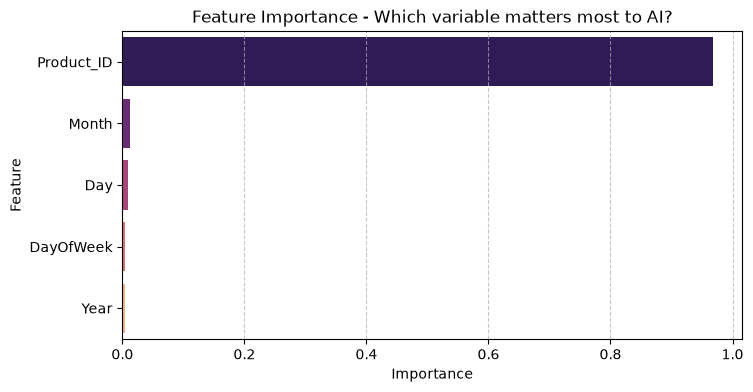

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract feature importance values from the trained model
importances = model.feature_importances_

# 2. Combine features and importances into a clear summary table
feature_imp_df = pd.DataFrame({
    'Feature': features, 
    'Importance': importances
}).sort_values(ascending=False, by='Importance')

# 3. Plot the feature importance graph using Seaborn
plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='magma')
plt.title('Feature Importance - Which variable matters most to AI?')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [14]:
import pandas as pd
df_big = pd.read_csv("foresight_final_processed.csv")
df_small = df_big.head(10000)
df_small.to_csv("foresight_final_processed.csv", index=False)
print("Success! The file size has been compressed.")

Success! The file size has been compressed.
